# 08 — Pipeline quotidien complet

Ce notebook reproduit la **routine quotidienne** : chaque matin, après la mesure HRV,
on importe le fichier, on calcule le score de readiness et on décide de la charge
d'entraînement du jour.

**Séquence complète :**
```
1. Lire le fichier Polar du matin
2. Créer RRSeries + nettoyer
3. Protocole resting HRV
4. Score readiness vs baseline personnelle
5. Décision d'entraînement (zone TSB + readiness)
6. Calculer le TRIMP prévu
7. Sauvegarder features + session d'entraînement
8. Afficher le dashboard du jour
```

**Prérequis :** notebook 00 (DB initialisée), notebooks 02–07 (comprendre chaque étape).

In [1]:
from pathlib import Path

from dotenv import load_dotenv

load_dotenv(Path("../.env"))

import matplotlib.pyplot as plt

import cardiolab
from cardiolab.analytics import Baseline, readiness_score_oura
from cardiolab.analytics.training_load import TrainingLoad, trimp_hrv_based
from cardiolab.database import HRVRepository
from cardiolab.labels import LABELS_FR
from cardiolab.protocols import resting_hrv
from cardiolab.reporting import (
    summary_training_load,
)
from cardiolab.sensors_tools.polar import parse_rr_file
from cardiolab.signals.rr import RRSeries
from cardiolab.visualization.resting_plots import plot_resting_evolution
from cardiolab.visualization.training_load_plots import (
    plot_atl_ctl_tsb,
    plot_trimp_history,
)

DATASETS_DIR = Path(cardiolab.__file__).parent / "datasets"
USER_ID_TEST = "demo-user"
print("✓  OK")

✓  OK


## Paramètres de la session du jour

Modifier ces variables pour refléter la session réelle.

In [2]:
# ── Paramètres à adapter ──────────────────────────────────────────────────────
TODAY_FILE = sorted((DATASETS_DIR / "raw" / "resting").glob("*.txt"))[-1]
TODAY_DATE = TODAY_FILE.stem[:10]
SPORT_TYPE = "running"  # type d'activité prévue
PLANNED_DURATION = 50.0  # durée prévue en minutes
# ─────────────────────────────────────────────────────────────────────────────

print(f"Session du jour : {TODAY_DATE}")
print(f"Fichier         : {TODAY_FILE.name}")
print(f"Sport prévu     : {SPORT_TYPE} — {PLANNED_DURATION:.0f} min")

Session du jour : 2026-04-30
Fichier         : 2026-04-30 07-01-38.txt
Sport prévu     : running — 50 min


## Étape 1–4 — Lecture, analyse, scoring

In [3]:
# Charger et analyser
raw = parse_rr_file(TODAY_FILE)
rr = RRSeries(raw["rr_intervals"]).remove_outliers()
features = resting_hrv(rr, compute_score=False)

# Construire la baseline depuis les sessions déjà en base
with HRVRepository.from_env() as repo:
    history = repo.load_features(USER_ID_TEST)

baseline = Baseline.from_features(history) if history else Baseline()
readiness = readiness_score_oura(features, baseline)
features.score = readiness

# Affichage
print(f"RMSSD     : {features.rmssd:.1f} ms")
print(f"DFA α1    : {features.dfa_alpha1:.3f}")
print(f"HR moyen  : {features.mean_hr:.1f} bpm")
print(f"\nReadiness : {readiness:.0f}/100", end="  ")

if readiness >= 65:
    print("🟢 Excellent — séance intense possible")
elif readiness >= 55:
    print("🟡 Bonne récupération — entraînement normal")
elif readiness >= 45:
    print("🟡 Normal — modérer l'intensité")
elif readiness >= 35:
    print("🟠 Légère fatigue — récupération active")
else:
    print("🔴 Fatigue élevée — repos recommandé")

RMSSD     : 81.9 ms
DFA α1    : 1.071
HR moyen  : 51.0 bpm

Readiness : 79/100  🟢 Excellent — séance intense possible


## Étape 5–6 — Décision d'entraînement et TRIMP

In [4]:
# Charger le TSB actuel
with HRVRepository.from_env() as repo:
    sessions = repo.load_training_sessions(USER_ID_TEST)

if sessions:
    tl = TrainingLoad.from_sessions(sessions)
    summary = summary_training_load(tl)
    tsb = summary["tsb"]
    print(f"TSB actuel : {tsb:+.1f}  ({summary['tsb_zone']})")
else:
    tsb = 0.0
    print("TSB : aucune session enregistrée (TSB = 0)")

# TRIMP prévu
trimp = trimp_hrv_based(PLANNED_DURATION, readiness)
print(f"\nTRIMP prévu pour {PLANNED_DURATION:.0f} min de {SPORT_TYPE} : {trimp:.1f}")

# Recommandation combinée TSB + readiness
if readiness < 40:
    rec = "Repos ou récupération légère — ne pas s'entraîner"
elif tsb < -20:
    rec = "TSB très négatif — réduire la durée de 30 %"
    PLANNED_DURATION *= 0.7
    trimp = trimp_hrv_based(PLANNED_DURATION, readiness)
elif tsb > 20 and readiness > 60:
    rec = "TSB positif + bonne récupération — séance intense bienvenue"
else:
    rec = "Séance modérée — objectif : maintenir la forme"

print(f"Recommandation : {rec}")
print(f"TRIMP ajusté   : {trimp:.1f}")

TSB actuel : -14.6  (accumulated_fatigue)

TRIMP prévu pour 50 min de running : 10.4
Recommandation : Séance modérée — objectif : maintenir la forme
TRIMP ajusté   : 10.4


## Étape 7 — Sauvegarder

In [5]:
SAVE_TO_DB = True  # passer à False pour un dry-run

if SAVE_TO_DB:
    features.date = TODAY_DATE  # save_features lit features.date

    with HRVRepository.from_env() as repo:
        # Sauvegarder les features HRV
        repo.save_features(features, user_id=USER_ID_TEST)

        # Sauvegarder les RR bruts
        repo.save_raw_session(
            rr,
            user_id=USER_ID_TEST,
            date=TODAY_DATE,
            protocol="resting",
            source_file=TODAY_FILE.name,
        )

        # Sauvegarder la session d'entraînement
        aid = repo.save_training_session(
            user_id=USER_ID_TEST,
            date=TODAY_DATE,
            duration_min=PLANNED_DURATION,
            sport_type=SPORT_TYPE,
            trimp=trimp,
        )

    print(f"✅  Sauvegardé — activity_id : {aid}")
else:
    print("Dry-run — rien n'est sauvegardé")

✅  Sauvegardé — activity_id : 8a7577e4-ab5e-4efc-8a67-42670f2c9f59


## Étape 8 — Dashboard du jour

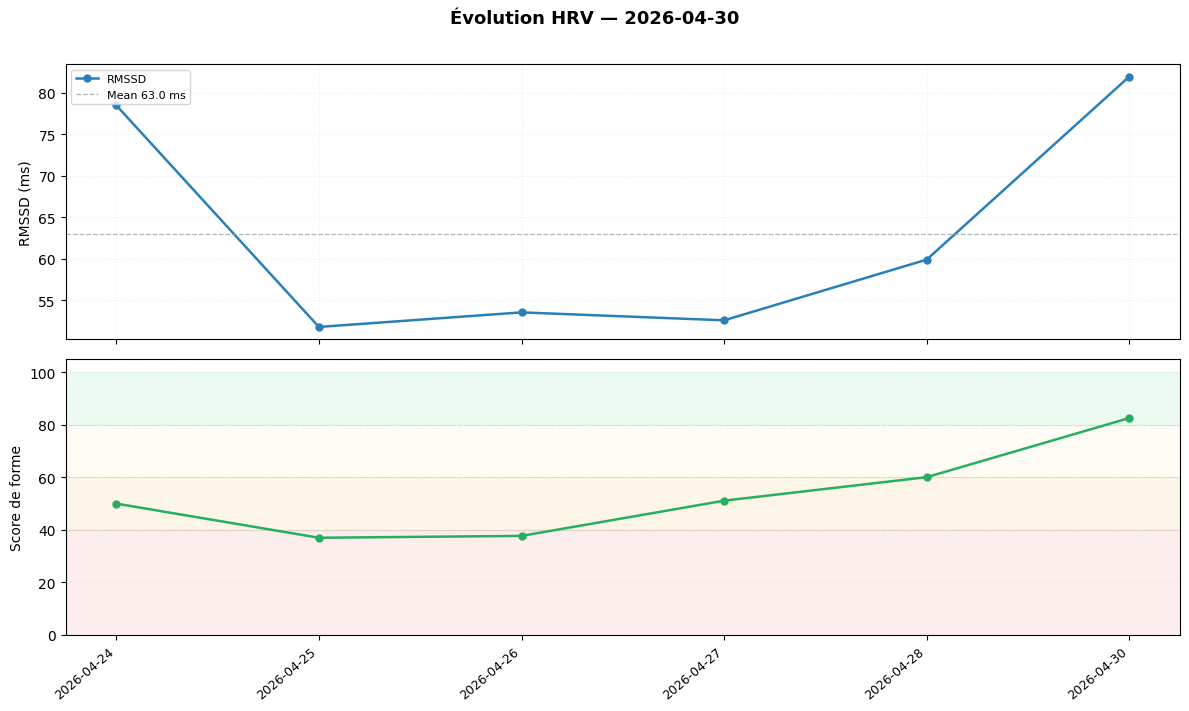

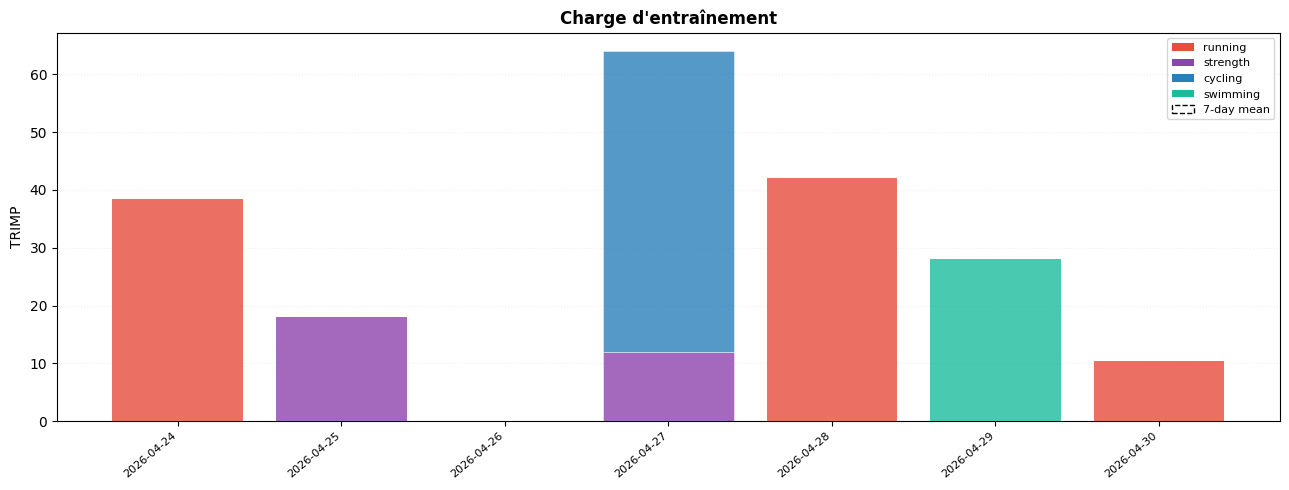

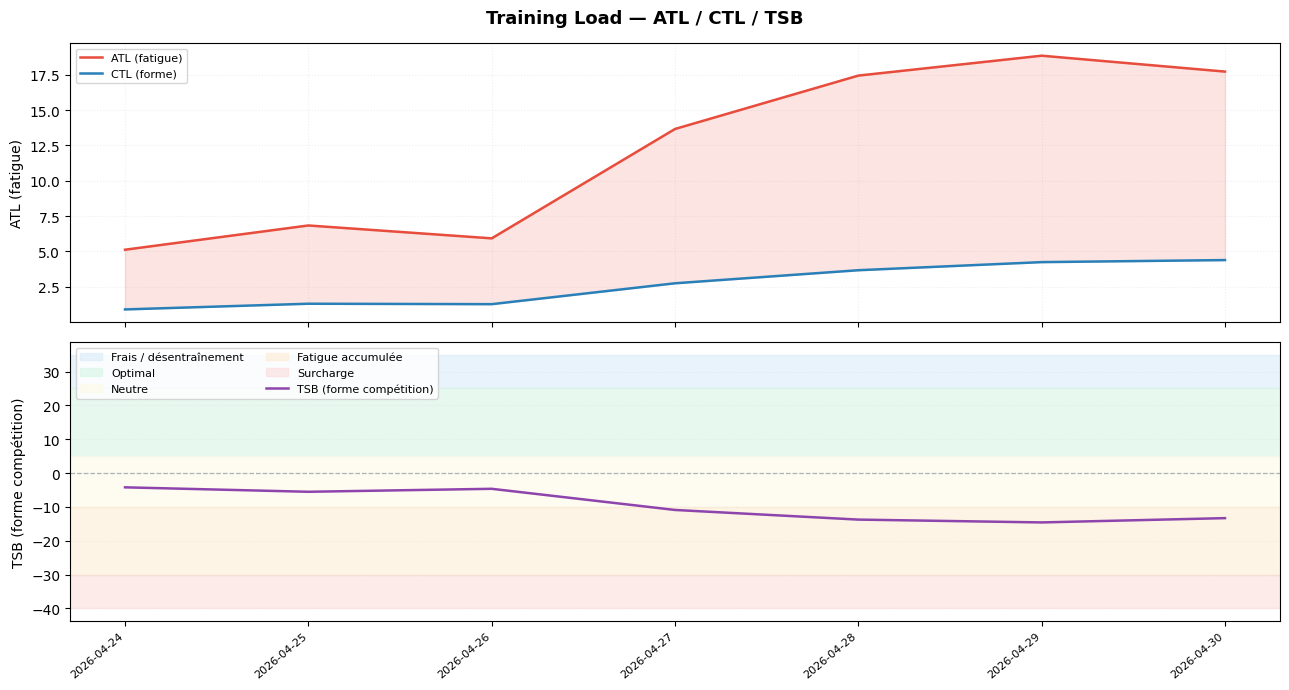

In [6]:
# Recharger l'historique complet mis à jour
with HRVRepository.from_env() as repo:
    history_updated = repo.load_features(USER_ID_TEST)
    sessions_updated = repo.load_training_sessions(USER_ID_TEST)

if history_updated:
    baseline_all = Baseline()
    scores_all = []
    dates_all = []
    for f in history_updated:
        sc = readiness_score_oura(f, baseline_all)
        f.score = sc
        scores_all.append(sc)
        dates_all.append(str(f.date))
        baseline_all.history.append(f)

    # Évolution HRV
    fig = plot_resting_evolution(
        history_updated,
        scores_all,
        session_labels=dates_all,
        labels=LABELS_FR,
        title=f"Évolution HRV — {TODAY_DATE}",
    )
    plt.show()

if sessions_updated:
    tl_updated = TrainingLoad.from_sessions(sessions_updated)

    fig = plot_trimp_history(
        tl_updated,
        sessions=sessions_updated,
        labels=LABELS_FR,
        title="Charge d'entraînement",
    )
    plt.show()

    fig = plot_atl_ctl_tsb(tl_updated, labels=LABELS_FR)
    plt.show()